# Plot results for offline prompting in the "dragon" example

In [1]:
%cd ..
%pwd  # should be "llm-adaptation"

C:\Users\micha\OneDrive - Univerzita Karlova\research\2024-LLM-DEECo\llm-adaptation


'C:\\Users\\micha\\OneDrive - Univerzita Karlova\\research\\2024-LLM-DEECo\\llm-adaptation'

In [2]:
from pathlib import Path
import pandas as pd
import shutil
import subprocess
import sys
import json
import matplotlib.pyplot as plt
from matplotlib.markers import MarkerStyle
import numpy as np

In [3]:
results_folder = Path("generated_adaptations/dragon")
pd.options.display.float_format = "{:,.1f}".format

## Run experiments

In [29]:
prompt = "generated_adaptations/prompts_user/dragon_strategy.md"
variants = {
    "system": "system",
    "constraints": "all",
    "stats": "stats",
    "result": "result",
}
llms = {
    # "5nanolow": "gpt-5-nano-2025-08-07,reasoning_effort=low",
    "5nano": "gpt-5-nano-2025-08-07",
    # "5mini": "gpt-5-mini-2025-08-07",
    # "5": "gpt-5-2025-08-07",
}
repeats = 1
start = 3

In [30]:
# import generated_adaptations.generator as generator

In [31]:
for variant, mode in variants.items():
    for llm_name, llm in llms.items():
        for repeat in range(start, start + repeats):
            folder_name = f"{llm_name}_{repeat:02d}"
            print(f"\n{variant}/{folder_name}\n")
            folder = results_folder / variant / folder_name
            folder.mkdir(parents=True, exist_ok=True)
            shutil.copy(prompt, folder / "01_user.md")
            cmd  = [sys.executable, "generated_adaptations/generator.py", f"--folder={str(folder)}", f"--llm={llm}", f"--mode={mode}"]
            result = subprocess.run(cmd, capture_output=True, text=True)  # even capture_output=False does not stream in real-time, so we rather capture it and print it later
            print(result.stdout)
            print(result.stderr)
            # generator.main([f"--folder={str(folder)}"])  # this also does not show the real-time output


system/5nano_03

Loaded 2 messages from generated_adaptations\dragon\system\5nano_03.
Querying LLM with prompt 01_user.
TOKENS USED:
Input: 1066, Output: 7726 (reasoning: 6784)
Response time (seconds): 55.3

LLM response saved to '02_llm.md'.
Code block saved to 'generated_adaptations\dragon\system\5nano_03\code_02.py'.
Running tests (system): pytest generated_adaptations/tests -q --tb=short -rfExXpP --show-capture=no --color=no --example=dragon --adaptation_name=5nano_03/code_02 --variant=system --tests=system
Test exit code: 0
Running tests (all): pytest generated_adaptations/tests -q --tb=short -rfExXpP --show-capture=no --color=no --example=dragon --adaptation_name=5nano_03/code_02 --variant=system --tests=all
Test exit code: 1
Running simulation for 'generated_adaptations\dragon\system\5nano_03\code_02.py'.
  Run #1/3: python main.py dragon/configs/default.yaml generated_adaptations/configs/generated.yaml DSL/dragon.yaml --extra_config={"name": "system/5nano_03/code_02", "log_dir

## Results

In [4]:
# folders = list(results_folder.glob("*/*"))
folders = list(results_folder.glob("*/5nano_*"))
# folders = list(results_folder.glob("*/5nanolow*"))
# folders = [results_folder / "41mini"]
print([(f.parent.stem, f.stem) for f in folders])

[('constraints', '5nano_01'), ('constraints', '5nano_02'), ('constraints', '5nano_03'), ('result', '5nano_01'), ('result', '5nano_02'), ('result', '5nano_03'), ('stats', '5nano_01'), ('stats', '5nano_02'), ('stats', '5nano_03'), ('system', '5nano_01'), ('system', '5nano_02'), ('system', '5nano_03')]


In [5]:
summary = pd.DataFrame(columns=["llm", "params", "repeat"])

for folder in folders:
    llm, repeat = folder.stem.split("_")
    params = folder.parent.stem
    summary.loc[len(summary), ["llm", "params", "repeat"]] = [llm, params, repeat]

    for file in (folder / "results").glob("*.txt"):
        name = file.stem.removeprefix("code_")
        code = name.split("_")[0]
        if "_missing" in name:
            summary.loc[len(summary) - 1, code + "_system"] = "missing"
            summary.loc[len(summary) - 1, code + "_result"] = "-"
        elif "_system_fail" in name:
            summary.loc[len(summary) - 1, code + "_system"] = "fail"
        elif "_system_pass" in name:
            summary.loc[len(summary) - 1, code + "_system"] = "pass"
        elif "_all_fail" in name:
            summary.loc[len(summary) - 1, code + "_user"] = "fail"
        elif "_all_pass" in name:
            summary.loc[len(summary) - 1, code + "_user"] = "pass"
        else:
            print(f"Unknown file: {file}")
    for file in (folder / "results").glob("*.json"):
        name = file.stem.removeprefix("code_")
        if "_simulation_result" in name:
            code = name.removesuffix("_simulation_result")
            results = json.load(open(file))
            # result = results["winrate"]
            result = results["steps"]
            if result is None:
                result = "-"
            summary.loc[len(summary) - 1, code + "_result"] = result
        else:
            print(f"Unknown file: {file}")

summary = summary.astype("object")
summary.fillna("", inplace=True)

C:\Users\micha\AppData\Local\Temp\ipykernel_36692\1107469740.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary.loc[len(summary) - 1, code + "_result"] = result
C:\Users\micha\AppData\Local\Temp\ipykernel_36692\1107469740.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary.loc[len(summary) - 1, code + "_result"] = result
C:\Users\micha\AppData\Local\Temp\ipykernel_36692\1107469740.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary.loc[l

In [6]:
summary.set_index(["llm", "params", "repeat"], inplace=True)

In [7]:
summary = summary.reindex(sorted(summary.columns), axis=1)

In [8]:
summary

02_result 02_system 02_user 04_result 04_system  \
llm   params      repeat                                                   
5nano constraints 01             -      fail    fail         -   missing   
                  02          13.3      pass    pass                       
                  03          15.3      pass    pass      12.0      pass   
      result      01             -      pass    fail         -      pass   
                  02             -   missing                 -      pass   
                  03             -      pass    fail         -      pass   
      stats       01             -      fail    fail         -      fail   
                  02             -      pass    fail         -      pass   
                  03             -      pass    fail      12.0      pass   
      system      01             -      pass    fail      15.3      pass   
                  02             -   missing                 -      pass   
                  03             -      pass    fail      15.0      pass   

                         04_user 06_result 06_system 06_user 08_result  ...  \
llm   params      repeat                                                ...   
5nano constraints 01                     -      pass    fail      12.0  ...   
                  02                                                    ...   
                  03        pass                                        ...   
      result      01        fail      15.3      pass    pass      12.0  ...   
                  02        fail         -      pass    fail         -  ...   
                  03        fail         -      pass    fail      15.3  ...   
      stats       01        fail         -      fail    fail         -  ...   
                  02        fail         -      pass    pass         -  ...   
                  03        pass                                        ...   
      system      01        pass      15.3      pass    pass      15.0  ...   
                  02        fail      12.0      pass    pass            ...   
                  03        fail                                        ...   

                         14_user 16_result 16_system 16_user 18_result  \
llm   params      repeat                                                 
5nano constraints 01                                                     
                  02                                                     
                  03                                                     
      result      01                                                     
                  02        pass         -      pass    fail      17.7   
                  03                                                     
      stats       01        fail         -      fail    fail         -   
                  02                                                     
                  03                                                     
      system      01                                                     
                  02                                                     
                  03                                                     

                         18_system 18_user 20_result 20_system 20_user  
llm   params      repeat                                                
5nano constraints 01                                                    
                  02                                                    
                  03                                                    
      result      01                                                    
                  02          pass    pass         -      pass    pass  
                  03                                                    
      stats       01          fail    fail         -      fail    fail  
                  02                                                    
                  03                                                    
      system 

### Plot

In [9]:
colors = {
    "5nano/constraints": "tab:blue",
    "5nano/system": "tab:green",
    "5nano/result": "tab:orange",
    "5nano/stats": "tab:red",
}

In [10]:
result_cols = [col for col in summary.columns if col.endswith("_result")]
plot_data = summary[result_cols].replace({"-": 30, "": np.nan}).astype(float)
plot_data

C:\Users\micha\AppData\Local\Temp\ipykernel_36692\2552851031.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plot_data = summary[result_cols].replace({"-": 30, "": np.nan}).astype(float)


02_result  04_result  06_result  08_result  \
llm   params      repeat                                               
5nano constraints 01           30.0       30.0       30.0       12.0   
                  02           13.3        NaN        NaN        NaN   
                  03           15.3       12.0        NaN        NaN   
      result      01           30.0       30.0       15.3       12.0   
                  02           30.0       30.0       30.0       30.0   
                  03           30.0       30.0       30.0       15.3   
      stats       01           30.0       30.0       30.0       30.0   
                  02           30.0       30.0       30.0       30.0   
                  03           30.0       12.0        NaN        NaN   
      system      01           30.0       15.3       15.3       15.0   
                  02           30.0       30.0       12.0        NaN   
                  03           30.0       15.0        NaN        NaN   

                          10_result  12_result  14_result  16_result  \
llm   params      repeat                                               
5nano constraints 01            NaN        NaN        NaN        NaN   
                  02            NaN        NaN        NaN        NaN   
                  03            NaN        NaN        NaN        NaN   
      result      01            NaN        NaN        NaN        NaN   
                  02           16.7       17.0       17.7       30.0   
                  03           12.0        NaN        NaN        NaN   
      stats       01           30.0       30.0       30.0       30.0   
                  02           14.5        NaN        NaN        NaN   
                  03            NaN        NaN        NaN        NaN   
      system      01            NaN        NaN        NaN        NaN   
                  02            NaN        NaN        NaN        NaN   
                  03            NaN        NaN        NaN        NaN   

                          18_result  20_result  
llm   params      repeat                        
5nano constraints 01            NaN        NaN  
                  02            NaN        NaN  
                  03            NaN        NaN  
      result      01            NaN        NaN  
                  02           17.7       30.0  
                  03            NaN        NaN  
      stats       01           30.0       30.0  
                  02            NaN        NaN  
                  03            NaN        NaN  
      system      01            NaN        NaN  
                  02            NaN        NaN  
                  03            NaN        NaN

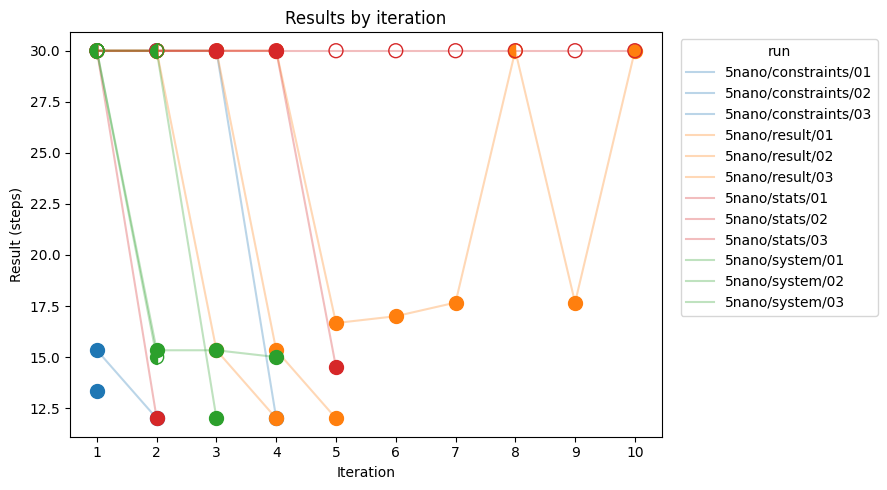

In [12]:
plot_df = plot_data.T.copy()  # index: result columns like `02_result`, columns: MultiIndex (llm, params, repeat)
orig_cols = plot_df.columns  # MultiIndex
labels = [f"{llm}/{params}/{repeat}" for llm, params, repeat in orig_cols]
x = list(range(1, len(plot_df.index) + 1))

fig, ax = plt.subplots(figsize=(9, 5))
for col, label in zip(orig_cols, labels):
    y = plot_df[col].values
    # draw the line for the run
    color = colors[label.rsplit("/", 1)[0]]
    line, = ax.plot(x, y, '-', label=label, alpha=0.3, color=color)

    # collect indices by test status
    pass_idx, half_idx, fail_idx = [], [], []
    for i, result_col in enumerate(plot_df.index):  # e.g. '02_result'
        system_col = result_col.replace('_result', '_system')
        user_col = result_col.replace('_result', '_user')

        system = summary.loc[col, system_col]
        user = summary.loc[col, user_col]

        if system == "pass" and user == "pass":
            pass_idx.append(i)
        elif system == "pass":
            half_idx.append(i)
        else:
            fail_idx.append(i)

    # overplot markers (use same color as the line)
    scatter_kwargs = {
        "zorder": 3, "s": 100, "alpha": 1
    }
    if pass_idx:
        ax.scatter([x[i] for i in pass_idx], [y[i] for i in pass_idx], marker='o', color=color, **scatter_kwargs)
    if half_idx:
        ax.scatter([x[i] for i in half_idx], [y[i] for i in half_idx], marker=MarkerStyle("o", fillstyle="left"), color=color, **scatter_kwargs)
        ax.scatter([x[i] for i in half_idx], [y[i] for i in half_idx], marker=MarkerStyle("o", fillstyle="right"), color="none", edgecolors=color, **scatter_kwargs)
    if fail_idx:
        ax.scatter([x[i] for i in fail_idx], [y[i] for i in fail_idx], marker='o', color=color, facecolors='none', **scatter_kwargs)

# finalize axes
ax.set_xticks(x)
ax.set_xticklabels(x)  # iterations 1,2,3,...
ax.set_xlabel("Iteration")
ax.set_ylabel("Result (steps)")
ax.set_title("Results by iteration")
ax.legend(title="run", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Iteration counts

In [41]:
iterations = summary.apply(lambda row: sum(1 for col in result_cols if row[col] != ""), axis=1, )
iterations = pd.DataFrame(iterations).rename(columns={0: "iterations"})
iterations

iterations
llm   params      repeat            
5nano constraints 01               4
                  02               1
                  03               2
      result      01               4
                  02              10
                  03               5
      stats       01              10
                  02               5
                  03               2
      system      01               4
                  02               3
                  03               2